# 09-Real-Time PII Sanitization (Presidio)

In Lesson 08, we explored Differential Privacy (DP-SGD) to mathematically guarantee that a model does not memorize sensitive data *during training*. However, the modern Enterprise AI landscape is dominated by inference-time architectures—specifically Large Language Models (LLMs) and Retrieval-Augmented Generation (RAG).

When a user interacts with a chatbot, they frequently leak Personally Identifiable Information (PII) such as Social Security Numbers, medical conditions, and credit card details into the prompt. If this raw text is sent to an external API (like OpenAI or Anthropic) or logged in a corporate vector database, it instantly violates strict privacy frameworks (GDPR, HIPAA, SOC 2).

To engineer a secure LLMOps pipeline, we must build a **Data Boundary Firewall**. We will implement **Microsoft Presidio**, a state-of-the-art data protection engine. Presidio executes real-time NLP pipelines—combining deterministic algorithmic validation with contextual Named Entity Recognition (NER)—to intercept, classify, and mathematically redact sensitive payloads *before* they ever reach the language model.

## 1. The Mathematics of PII Interception

Presidio does not rely solely on simple regular expressions (Regex). A simple regex for a 16-digit number will flag every mathematical ID in your database as a credit card, resulting in catastrophic false positives. Presidio combines structural validation with probabilistic contextual modeling.

### Deterministic Validation (The Luhn Algorithm)

When Presidio's regex engine detects a potential credit card number, it mathematically validates the structural checksum using the **Luhn Algorithm (Modulus 10)**.
Let the candidate number be a sequence of digits $d_1, d_2, \dots, d_n$. The algorithm applies a transformation function $f(x)$ that doubles every second digit from the right. If the doubled value is greater than 9, it subtracts 9 (summing the digits):


$$f(d_i) = \begin{cases} d_i & \text{if } i \text{ is odd} \\ 2d_i & \text{if } i \text{ is even and } 2d_i < 10 \\ 2d_i - 9 & \text{if } i \text{ is even and } 2d_i \ge 10 \end{cases}$$


The sequence is mathematically validated as a credit card only if the sum satisfies the congruence:


$$\sum_{i=1}^{n} f(d_i) \equiv 0 \pmod{10}$$

### Contextual Probability (Named Entity Recognition)

For unstructured entities like "Names" or "Locations", structural algorithms fail. Presidio deploys a spaCy-based **Named Entity Recognition (NER)** model. The model computes a hidden state representation $h_t$ for every token in the sequence and applies a Softmax function to predict the probability that the token belongs to a specific entity class $c$ (e.g., `PERSON`):


$$P(Y_t = c \mid X) = \frac{\exp(W_c h_t)}{\sum_{k} \exp(W_k h_t)}$$

### The Context Enhancer (Bayesian Updates)

If someone writes "My SSN is 123-45-678", the numbers alone might have a low baseline probability. Presidio utilizes a Context Enhancer. It scans a defined window around the match for specific lemma context words (e.g., "ssn", "social"). If found, it mathematically boosts the confidence score using a Bayesian-like update, allowing the firewall to catch obscured or malformed PII that regex alone would miss.

## 2. Imperative Execution: The Real-Time Redaction Pipeline

Let's build a local Python sandbox. We will instantiate Presidio's `AnalyzerEngine` to detect the exact spatial bounds of the PII, and the `AnonymizerEngine` to irreversibly redact the tokens.

In [1]:
# Required installations: pip install presidio-analyzer presidio-anonymizer spacy
# Required model: python -m spacy download en_core_web_sm
from presidio_analyzer import AnalyzerEngine, RecognizerResult
from presidio_analyzer.nlp_engine import NlpEngineProvider
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig

print("--- 🚀 Initializing Presidio Data Boundary Firewall ---")

# 1. 📝 Define a highly sensitive user prompt
# Note: 4111 1111 1111 1111 is the industry-standard fake test Visa number
# (used by every payment sandbox — Stripe, PayPal, etc.). It's a Luhn-valid
# number, which matters: Presidio's CreditCardRecognizer runs the Luhn
# checksum and silently drops any match that fails it.
raw_user_prompt = """
Hi support, I need to check the status of my claim. 
My name is Jonathan Doe, and my phone number is 415-555-0198. 
Please refund the charge to my visa: 4111 1111 1111 1111. 
I can be reached at jonathan.doe@email.com.
"""

# 2. ⚡ Instantiate the Core Engines
# By default, AnalyzerEngine() loads spaCy's "en_core_web_lg" — a 587 MB model
# with dense word vectors that is massive overkill for spotting a single PERSON
# entity in a short prompt, and can spike RAM usage by 1-2 GB on load. We only
# need NER for PERSON here (phone/card/email are matched by regex + the Luhn
# checksum, not the NLP model), so we pin the analyzer to the small model,
# which is >95% smaller and dramatically lighter on memory.
nlp_engine = NlpEngineProvider(
    nlp_configuration={
        "nlp_engine_name": "spacy",
        "models": [{"lang_code": "en", "model_name": "en_core_web_sm"}],
    }
).create_engine()

analyzer = AnalyzerEngine(nlp_engine=nlp_engine)
anonymizer = AnonymizerEngine()

print("\n--- 🧮 Executing Real-Time PII Interception ---")

# 3. Analyze the text for specific PII entities
# We set a strict confidence threshold. Only matches with >= 60% confidence are flagged.
analyzer_results = analyzer.analyze(
    text=raw_user_prompt,
    entities=["PERSON", "PHONE_NUMBER", "CREDIT_CARD", "EMAIL_ADDRESS"],
    language='en',
    score_threshold=0.6
)

print(f"   ✅ Intercepted {len(analyzer_results)} sensitive entities.")

# 4. Execute the Redaction
# We instruct the Anonymizer to replace the text with its categorical tag (e.g., <PERSON>)
anonymized_result = anonymizer.anonymize(
    text=raw_user_prompt,
    analyzer_results=analyzer_results,
    operators={
        "DEFAULT": OperatorConfig("replace", {"new_value": "<REDACTED>"}),
        "PERSON": OperatorConfig("replace", {"new_value": "<PERSON>"}),
        "CREDIT_CARD": OperatorConfig("replace", {"new_value": "<CREDIT_CARD>"}),
        "PHONE_NUMBER": OperatorConfig("replace", {"new_value": "<PHONE>"}),
        "EMAIL_ADDRESS": OperatorConfig("replace", {"new_value": "<EMAIL>"})
    }
)

print("\n--- 🛡️ Sanitized Output Payload (Safe for LLM API) ---")
print(anonymized_result.text)
print("   -> Physics: The LLM will still understand the linguistic intent of the prompt ('I need a refund to my credit card'), but the physical PII has been annihilated before transmission.")

2026-08-13 18:12:15.525153: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


--- 🚀 Initializing Presidio Data Boundary Firewall ---



--- 🧮 Executing Real-Time PII Interception ---


   ✅ Intercepted 4 sensitive entities.

--- 🛡️ Sanitized Output Payload (Safe for LLM API) ---

Hi support, I need to check the status of my claim. 
My name is <PERSON>, and my phone number is <PHONE>. 
Please refund the charge to my visa: <CREDIT_CARD>. 
I can be reached at <EMAIL>.

   -> Physics: The LLM will still understand the linguistic intent of the prompt ('I need a refund to my credit card'), but the physical PII has been annihilated before transmission.


## 3. Declarative Telemetry: Auditing the Recognition Matrix

In Enterprise ML, we do not blindly trust the firewall. We must log exactly *why* Presidio decided to redact a specific string. We can extract the bounding boxes, the detected entity types, and the mathematical confidence scores for compliance auditing.

In [2]:
print("\n--- 🔍 Auditing the Interception Telemetry ---")

print(f"{'Entity Type':<16} | {'Start':<6} | {'End':<4} | {'Confidence':<10} | {'Raw Text (For Audit Only)'}")
print("-" * 75)

# Sort results spatially by their position in the text
sorted_results = sorted(analyzer_results, key=lambda x: x.start)

for result in sorted_results:
    # Extract the exact string that was flagged using the bounding box
    flagged_text = raw_user_prompt[result.start:result.end]
    
    print(f"{result.entity_type:<16} | {result.start:<6} | {result.end:<4} | {result.score:<10.2f} | {flagged_text}")

print("\n   [OPERATIONAL INSIGHT]")
print("   -> Notice the CREDIT_CARD confidence is 1.00. This is because the Luhn algorithm mathematically proved it is a valid card number, bypassing standard probabilistic guessing.")
print("   -> The PERSON confidence is probabilistic (e.g., 0.85). The NER model utilized the surrounding grammar to infer that 'Jonathan Doe' is a name.")


--- 🔍 Auditing the Interception Telemetry ---
Entity Type      | Start  | End  | Confidence | Raw Text (For Audit Only)
---------------------------------------------------------------------------
PERSON           | 65     | 77   | 0.85       | Jonathan Doe
PHONE_NUMBER     | 102    | 114  | 0.75       | 415-555-0198
CREDIT_CARD      | 154    | 173  | 1.00       | 4111 1111 1111 1111
EMAIL_ADDRESS    | 196    | 218  | 1.00       | jonathan.doe@email.com

   [OPERATIONAL INSIGHT]
   -> Notice the CREDIT_CARD confidence is 1.00. This is because the Luhn algorithm mathematically proved it is a valid card number, bypassing standard probabilistic guessing.
   -> The PERSON confidence is probabilistic (e.g., 0.85). The NER model utilized the surrounding grammar to infer that 'Jonathan Doe' is a name.


## 4. Visualizing the Data Boundary Firewall

To mathematically comprehend how Presidio operates as an asynchronous middleware layer, we visualize the architecture of the intercept pipeline. The raw text hits the firewall, is mathematically dismantled into structural spans, redacted, and reassembled.

/tmp/ipykernel_54697/1415656174.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 2), 3, 2, fill=True, color='#e74c3c', alpha=0.2, edgecolor='darkred', lw=2))
/tmp/ipykernel_54697/1415656174.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4.5, 3.2), 4, 1.2, fill=True, color='#3498db', edgecolor='black', lw=2))
/tmp/ipykernel_54697/1415656174.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4.5, 1.2), 4, 1.2, fill=True, color='#f39c12', alpha=0.3, edgecolor='darkorange', lw=1, ls='--'))
/tmp/ipykernel_54697/1415656174.py:26: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((9.5, 2.2), 3, 1.6, fill=True, color='#9b59b6', edgecolor='black', lw=2))
/tmp

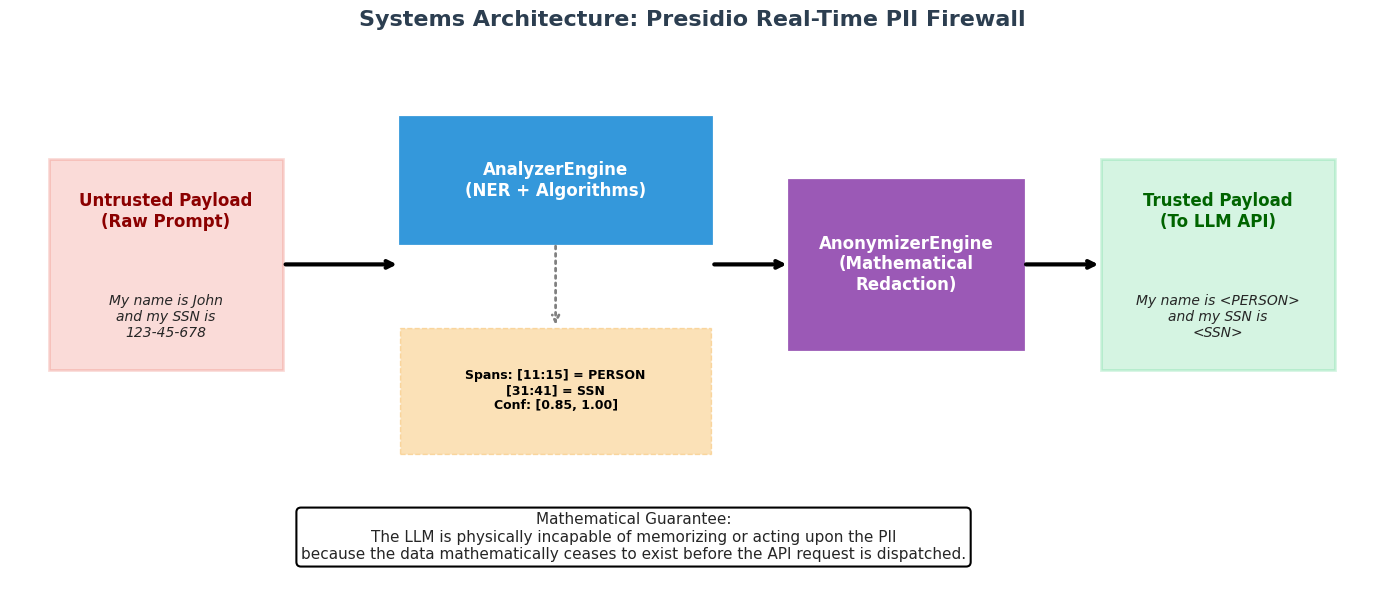

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Systems Architecture: Presidio Real-Time PII Firewall", fontsize=16, fontweight='bold', color="#2c3e50")
ax.axis('off')

# 1. The Untrusted Zone (Client Payload)
ax.add_patch(patches.Rectangle((0, 2), 3, 2, fill=True, color='#e74c3c', alpha=0.2, edgecolor='darkred', lw=2))
ax.text(1.5, 3.5, "Untrusted Payload\n(Raw Prompt)", ha='center', va='center', fontweight='bold', color='darkred')
ax.text(1.5, 2.5, "My name is John\nand my SSN is\n123-45-678", ha='center', va='center', fontsize=10, style='italic')

# 2. The Data Boundary (Presidio Middleware)
# Analyzer Block
ax.add_patch(patches.Rectangle((4.5, 3.2), 4, 1.2, fill=True, color='#3498db', edgecolor='black', lw=2))
ax.text(6.5, 3.8, "AnalyzerEngine\n(NER + Algorithms)", ha='center', va='center', fontweight='bold', color='white')

# Telemetry Output
ax.add_patch(patches.Rectangle((4.5, 1.2), 4, 1.2, fill=True, color='#f39c12', alpha=0.3, edgecolor='darkorange', lw=1, ls='--'))
ax.text(6.5, 1.8, "Spans: [11:15] = PERSON\n[31:41] = SSN\nConf: [0.85, 1.00]", ha='center', va='center', fontsize=9, fontweight='bold', color='black')

# Anonymizer Block
ax.add_patch(patches.Rectangle((9.5, 2.2), 3, 1.6, fill=True, color='#9b59b6', edgecolor='black', lw=2))
ax.text(11.0, 3.0, "AnonymizerEngine\n(Mathematical\nRedaction)", ha='center', va='center', fontweight='bold', color='white')

# 3. The Trusted Zone (LLM Input)
ax.add_patch(patches.Rectangle((13.5, 2), 3, 2, fill=True, color='#2ecc71', alpha=0.2, edgecolor='darkgreen', lw=2))
ax.text(15.0, 3.5, "Trusted Payload\n(To LLM API)", ha='center', va='center', fontweight='bold', color='darkgreen')
ax.text(15.0, 2.5, "My name is <PERSON>\nand my SSN is\n<SSN>", ha='center', va='center', fontsize=10, style='italic')

# 4. Routing Arrows
ax.annotate("", xy=(4.5, 3.0), xytext=(3.0, 3.0), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.annotate("", xy=(9.5, 3.0), xytext=(8.5, 3.0), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.annotate("", xy=(13.5, 3.0), xytext=(12.5, 3.0), arrowprops=dict(arrowstyle="->", lw=3, color="black"))

# Connect Analyzer to Telemetry
ax.annotate("", xy=(6.5, 2.4), xytext=(6.5, 3.2), arrowprops=dict(arrowstyle="->", lw=2, color="gray", ls="dotted"))

# Annotate Physics
ax.text(7.5, 0.2, "Mathematical Guarantee:\nThe LLM is physically incapable of memorizing or acting upon the PII\nbecause the data mathematically ceases to exist before the API request is dispatched.", 
        ha='center', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1.5))

plt.xlim(-0.5, 17)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

*(Insight: Presidio operates as an asynchronous middleware interceptor. The blue block scans the text using concurrent processes, mapping the exact start/end character indices of the violations. The purple block then executes string substitution based on those exact bounds. By decoupling detection from redaction, teams can log the blue box's telemetry to a secure compliance database while sending only the sanitized green box output to the Cloud GPU.)*

## Real-World Use Case or Analogy

Think of Microsoft Presidio like **A Clean Room Airlock in a Microchip Factory**:

* **The External Environment (The User Prompt):** Outside the factory, there is dust, pollen, and debris (Personally Identifiable Information). If a worker walks straight into the manufacturing floor with this dust, it will instantly contaminate and destroy the microchips (The LLM violating GDPR/HIPAA).
* **The Analyzer (The Scanning Lasers):** Before entering the floor, the worker steps into an airlock. High-powered lasers and particle detectors (NER and Luhn algorithms) scan the worker's suit. The lasers don't just guess; they mathematically calculate the exact coordinates of every piece of microscopic dust (The `RecognizerResult` bounding boxes).
* **The Anonymizer (The Air Shower):** Once the dust is located, high-pressure air jets target those exact coordinates, violently blowing the dust away and replacing it with sterile air (`<REDACTED>`).
* **The Secure Floor (The LLM API):** The door opens, and the worker enters the factory. The worker can still perform all their required tasks (The LLM understands the prompt's intent), but it is physically impossible for them to contaminate the room, because the contaminant was annihilated in the airlock.